In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Định nghĩa tên cột theo tài liệu của NASA
columns = ['id', 'cycle', 'setting1', 'setting2', 'setting3'] + [f's{i}' for i in range(1, 22)]

# Load dữ liệu (Đổi đường dẫn nếu cần)
train_df = pd.read_csv('train_FD001.txt', sep='\s+', header=None, names=columns)
test_df = pd.read_csv('test_FD001.txt', sep='\s+', header=None, names=columns)
truth_df = pd.read_csv('RUL_FD001.txt', sep='\s+', header=None, names=['RUL_real'])

print("Kích thước tập train:", train_df.shape)
print("Kích thước tập test:", test_df.shape)
print("Kích thước tập truth:", truth_df.shape)

Kích thước tập train: (20631, 26)
Kích thước tập test: (13096, 26)
Kích thước tập truth: (100, 1)


In [2]:
print(train_df.head())

   id  cycle  setting1  setting2  setting3      s1      s2       s3       s4  \
0   1      1   -0.0007   -0.0004     100.0  518.67  641.82  1589.70  1400.60   
1   1      2    0.0019   -0.0003     100.0  518.67  642.15  1591.82  1403.14   
2   1      3   -0.0043    0.0003     100.0  518.67  642.35  1587.99  1404.20   
3   1      4    0.0007    0.0000     100.0  518.67  642.35  1582.79  1401.87   
4   1      5   -0.0019   -0.0002     100.0  518.67  642.37  1582.85  1406.22   

      s5  ...     s12      s13      s14     s15   s16  s17   s18    s19  \
0  14.62  ...  521.66  2388.02  8138.62  8.4195  0.03  392  2388  100.0   
1  14.62  ...  522.28  2388.07  8131.49  8.4318  0.03  392  2388  100.0   
2  14.62  ...  522.42  2388.03  8133.23  8.4178  0.03  390  2388  100.0   
3  14.62  ...  522.86  2388.08  8133.83  8.3682  0.03  392  2388  100.0   
4  14.62  ...  522.19  2388.04  8133.80  8.4294  0.03  393  2388  100.0   

     s20      s21  
0  39.06  23.4190  
1  39.00  23.4236  
2  38.95

In [3]:
print(test_df.head())

   id  cycle  setting1  setting2  setting3      s1      s2       s3       s4  \
0   1      1    0.0023    0.0003     100.0  518.67  643.02  1585.29  1398.21   
1   1      2   -0.0027   -0.0003     100.0  518.67  641.71  1588.45  1395.42   
2   1      3    0.0003    0.0001     100.0  518.67  642.46  1586.94  1401.34   
3   1      4    0.0042    0.0000     100.0  518.67  642.44  1584.12  1406.42   
4   1      5    0.0014    0.0000     100.0  518.67  642.51  1587.19  1401.92   

      s5  ...     s12      s13      s14     s15   s16  s17   s18    s19  \
0  14.62  ...  521.72  2388.03  8125.55  8.4052  0.03  392  2388  100.0   
1  14.62  ...  522.16  2388.06  8139.62  8.3803  0.03  393  2388  100.0   
2  14.62  ...  521.97  2388.03  8130.10  8.4441  0.03  393  2388  100.0   
3  14.62  ...  521.38  2388.05  8132.90  8.3917  0.03  391  2388  100.0   
4  14.62  ...  522.15  2388.03  8129.54  8.4031  0.03  390  2388  100.0   

     s20      s21  
0  38.86  23.3735  
1  39.02  23.3916  
2  39.08

In [4]:
print(truth_df.head())

   RUL_real
0       112
1        98
2        69
3        82
4        91


Các cột có giá trị không đổi (cần loại bỏ): ['setting3', 's1', 's5', 's10', 's16', 's18', 's19']


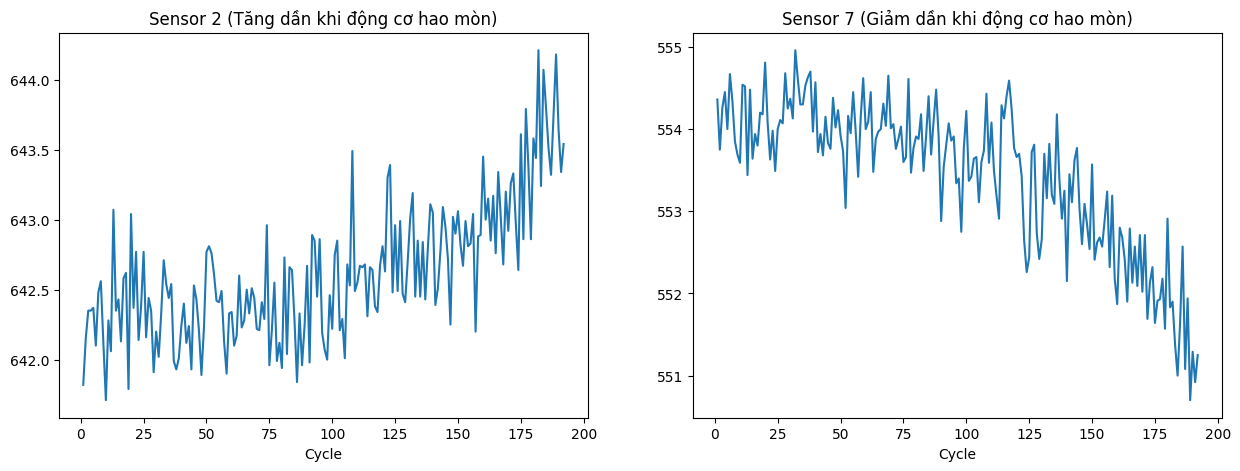

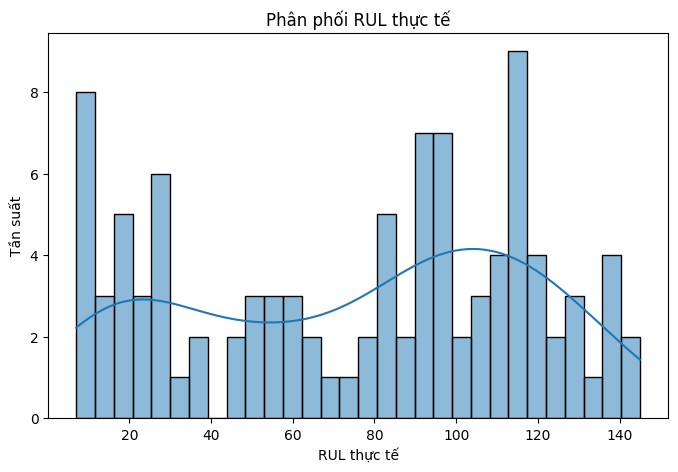

In [5]:
# Kiểm tra các cảm biến có giá trị không đổi (phương sai = 0)
nunique_train = train_df.nunique()
constant_columns = nunique_train[nunique_train == 1].index.tolist()
print("Các cột có giá trị không đổi (cần loại bỏ):", constant_columns)

# Vẽ biểu đồ xu hướng của một vài cảm biến theo chu kỳ (Cycle) cho Động cơ ID = 1
engine_1 = train_df[train_df['id'] == 1]

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(engine_1['cycle'], engine_1['s2'])
plt.title('Sensor 2 (Tăng dần khi động cơ hao mòn)')
plt.xlabel('Cycle')

plt.subplot(1, 2, 2)
plt.plot(engine_1['cycle'], engine_1['s7'])
plt.title('Sensor 7 (Giảm dần khi động cơ hao mòn)')
plt.xlabel('Cycle')
plt.show()

# Vẽ biểu đồ phân phối của RUL thực tế
plt.figure(figsize=(8, 5))
sns.histplot(truth_df['RUL_real'], bins=30, kde=True)
plt.title('Phân phối RUL thực tế')
plt.xlabel('RUL thực tế')
plt.ylabel('Tần suất')
plt.show()


In [6]:
# Tìm số chu kỳ tối đa của mỗi động cơ
rul_train = pd.DataFrame(train_df.groupby('id')['cycle'].max()).reset_index()
rul_train.columns = ['id', 'max_cycle']

# Ghép (merge) lại vào tập train
train_df = train_df.merge(rul_train, on=['id'], how='left')

# Tính RUL thực tế
train_df['RUL'] = train_df['max_cycle'] - train_df['cycle']

# Áp dụng Piecewise RUL (Giới hạn tối đa RUL ở mức 125)
RUL_MAX = 125
train_df['RUL'] = train_df['RUL'].clip(upper=RUL_MAX)

# Xóa cột max_cycle vì không cần thiết nữa
train_df.drop('max_cycle', axis=1, inplace=True)

In [7]:
from sklearn.preprocessing import MinMaxScaler

# 4.1 Loại bỏ các cột không có thông tin từ bước EDA
cols_to_drop = ['setting3', 's1', 's5', 's10', 's16', 's18', 's19']
train_df.drop(columns=cols_to_drop, inplace=True)
test_df.drop(columns=cols_to_drop, inplace=True)

# Các cột cảm biến còn lại để tạo đặc trưng
sensor_cols = [col for col in train_df.columns if col.startswith('s')]

# 4.2 Feature Engineering: Rolling window (Kích thước cửa sổ = 5 chu kỳ)
window_size = 5

def add_rolling_features(df, sensor_cols, window):
    df_out = df.copy()
    for col in sensor_cols:
        # Tính theo từng động cơ (groupby 'id')
        df_out[f'{col}_roll_mean'] = df_out.groupby('id')[col].rolling(window, min_periods=1).mean().reset_index(0, drop=True)
        df_out[f'{col}_roll_std'] = df_out.groupby('id')[col].rolling(window, min_periods=1).std().reset_index(0, drop=True)
        # Điền giá trị 0 cho các giá trị NaN sinh ra do hàm std
        df_out[f'{col}_roll_std'] = df_out[f'{col}_roll_std'].fillna(0)
    return df_out

train_df = add_rolling_features(train_df, sensor_cols, window_size)
test_df = add_rolling_features(test_df, sensor_cols, window_size)

# 4.3 Chuẩn hóa dữ liệu (Scaling)
# Chỉ fit trên tập Train, sau đó transform cho cả Train và Test để tránh Data Leakage
features = [c for c in train_df.columns if c not in ['id', 'cycle', 'RUL']]

scaler = MinMaxScaler()
train_df[features] = scaler.fit_transform(train_df[features])
test_df[features] = scaler.transform(test_df[features])

print("Hoàn tất xử lý! Số lượng đặc trưng hiện tại:", len(features))

Hoàn tất xử lý! Số lượng đặc trưng hiện tại: 51


In [8]:
# Xuât dữ liệu đã xử lý ra file CSV (nếu cần)
train_df.to_csv('train_processed.csv', index=False)

In [9]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error

# 1.1 Chuẩn bị tập Train
X_train = train_df[features]
y_train = train_df['RUL']

# 1.2 Chuẩn bị tập Test (Chỉ lấy chu kỳ cuối cùng của mỗi động cơ)
last_cycle_test = test_df.groupby('id').last().reset_index()
X_test = last_cycle_test[features]
y_test = truth_df['RUL_real'] # Dữ liệu RUL thực tế đã load ở bước 1

print("Kích thước X_train:", X_train.shape)
print("Kích thước X_test:", X_test.shape)

Kích thước X_train: (20631, 51)
Kích thước X_test: (100, 51)


In [10]:
from sklearn.model_selection import RandomizedSearchCV

# 1. Định nghĩa không gian tìm kiếm (Hyperparameter Grid)
param_grid = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9]
}

# 2. Khởi tạo mô hình cơ sở
xgb_base = xgb.XGBRegressor(random_state=42)

# 3. Thiết lập RandomizedSearchCV
# n_iter=20: Thuật toán sẽ thử ngẫu nhiên 20 tổ hợp khác nhau (tăng lên nếu bạn có thời gian)
# cv=3: Chia tập Train làm 3 phần để kiểm tra chéo (Cross-Validation)
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=20,
    scoring='neg_root_mean_squared_error', # Tối ưu hóa theo RMSE
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1 # Sử dụng toàn bộ sức mạnh CPU
)

# 4. Bắt đầu tìm kiếm
print("Đang tiến hành Hyperparameter Tuning. Vui lòng đợi trong ít phút...")
random_search.fit(X_train, y_train)

# In ra kết quả tốt nhất
print("\nHoàn tất! Các tham số tối ưu nhất tìm được là:")
print(random_search.best_params_)

Đang tiến hành Hyperparameter Tuning. Vui lòng đợi trong ít phút...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Hoàn tất! Các tham số tối ưu nhất tìm được là:
{'subsample': 0.6, 'n_estimators': 400, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.6}


In [11]:
# 1. Lấy mô hình xuất sắc nhất
best_xgb_model = random_search.best_estimator_

# 2. Dự đoán trên tập Test
y_pred_tuned = best_xgb_model.predict(X_test)
y_pred_tuned = np.maximum(y_pred_tuned, 0) # Ép RUL dự đoán không bị âm

# 3. Tính lại RMSE
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
print(f"Độ lỗi RMSE sau khi Tuning: {rmse_tuned:.2f} chu kỳ")


Độ lỗi RMSE sau khi Tuning: 18.56 chu kỳ


Độ lỗi RMSE trên tập Test: 18.56 chu kỳ
Điểm số NASA Score: 992.26


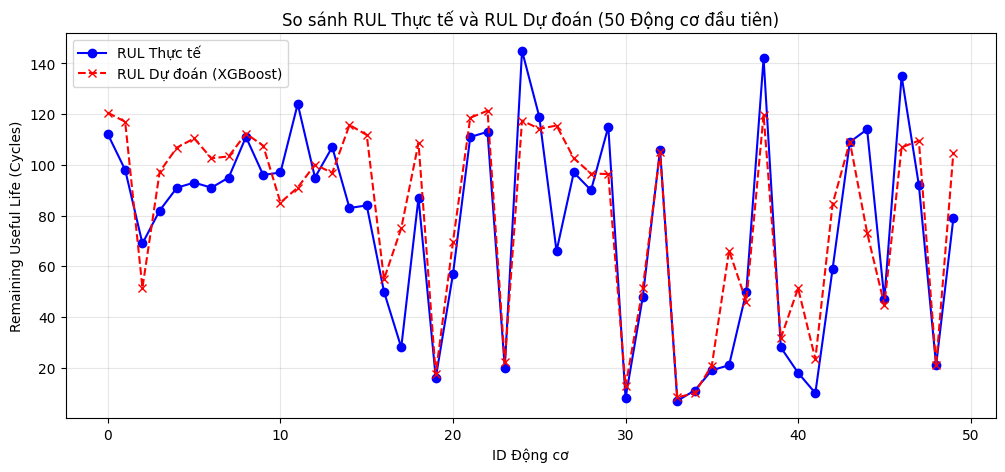

In [12]:
# 3.1 Dự đoán trên tập Test
model_to_use = best_xgb_model if 'best_xgb_model' in globals() else random_search.best_estimator_
y_pred = model_to_use.predict(X_test)

# Do RUL không thể âm, ta ép các giá trị dự đoán âm (nếu có) về 0
y_pred = np.maximum(y_pred, 0)

# 3.2 Tính RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Độ lỗi RMSE trên tập Test: {rmse:.2f} chu kỳ")

# 3.3 Tính hàm Score của NASA
def nasa_score(y_true, y_pred):
    score = 0
    for true, pred in zip(y_true, y_pred):
        error = pred - true
        if error < 0:
            score += np.exp(-error / 13) - 1  # Dự đoán sớm (Early prediction)
        else:
            score += np.exp(error / 10) - 1   # Dự đoán trễ (Late prediction)
    return score

score = nasa_score(y_test, y_pred)
print(f"Điểm số NASA Score: {score:.2f}")

# 3.4 Vẽ biểu đồ so sánh Thực tế vs Dự đoán cho 50 động cơ đầu tiên
plt.figure(figsize=(12, 5))
plt.plot(y_test[:50].values, label='RUL Thực tế', marker='o', linestyle='-', color='blue')
plt.plot(y_pred[:50], label='RUL Dự đoán (XGBoost)', marker='x', linestyle='--', color='red')
plt.title('So sánh RUL Thực tế và RUL Dự đoán (50 Động cơ đầu tiên)')
plt.xlabel('ID Động cơ')
plt.ylabel('Remaining Useful Life (Cycles)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [13]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

# Cài đặt độ dài của cửa sổ thời gian (sequence_length)
sequence_length = 50

# Hàm tạo các chuỗi dữ liệu (X) cho LSTM
def gen_sequence(id_df, seq_length, seq_cols):
    data_matrix = id_df[seq_cols].values
    num_elements = data_matrix.shape[0]
    # Lặp qua dữ liệu để cắt thành các cửa sổ trượt
    for start, stop in zip(range(0, num_elements - seq_length), range(seq_length, num_elements)):
        yield data_matrix[start:stop, :]

# Hàm tạo nhãn (y) tương ứng với chu kỳ cuối cùng của mỗi cửa sổ
def gen_labels(id_df, seq_length, label):
    data_matrix = id_df[label].values
    num_elements = data_matrix.shape[0]
    return data_matrix[seq_length:num_elements, :]

In [14]:
from tensorflow.keras.callbacks import EarlyStopping

# Khởi tạo lại mô hình (để reset các trọng số cũ)
model = Sequential()
# Tạo dữ liệu chuỗi (sequences) cho LSTM từ tập Train
X_train_lstm, y_train_lstm = [], []

for engine_id in train_df['id'].unique():
    id_df = train_df[train_df['id'] == engine_id]
    for seq in gen_sequence(id_df, sequence_length, features):
        X_train_lstm.append(seq)
    labels = gen_labels(id_df, sequence_length, ['RUL'])
    for label in labels:
        y_train_lstm.append(label)

X_train_lstm = np.asarray(X_train_lstm, dtype=np.float32)
y_train_lstm = np.asarray(y_train_lstm, dtype=np.float32)

print("Kích thước X_train_lstm:", X_train_lstm.shape)
print("Kích thước y_train_lstm:", y_train_lstm.shape)

model.add(LSTM(input_shape=(sequence_length, X_train_lstm.shape[2]), units=100, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=1, activation='relu'))

model.compile(loss='mean_squared_error', optimizer='adam')

# Cấu hình Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=10,        # Nếu sau 10 epochs mà val_loss không giảm thì dừng
    restore_best_weights=True # Lấy lại trọng số của epoch tốt nhất
)

# Huấn luyện lại với cấu hình mới
print("Đang huấn luyện lại mạng LSTM với Early Stopping...")
history_new = model.fit(
    X_train_lstm, y_train_lstm,
    epochs=100,         # Tăng số vòng lặp tối đa
    batch_size=64,      # Giảm batch_size xuống để học chi tiết hơn
    validation_split=0.1,
    callbacks=[early_stop], # Thêm Early Stopping
    verbose=1
)

# Đánh giá lại trên tập Test
# Build seq_array_test_last for prediction
seq_array_test_last = []
ids_test = []

for engine_id in sorted(test_df['id'].unique()):
    id_df = test_df[test_df['id'] == engine_id]
    data = id_df[features].values

    if data.shape[0] >= sequence_length:
        seq = data[-sequence_length:, :]
    else:
        pad = np.repeat(data[:1, :], sequence_length - data.shape[0], axis=0)
        seq = np.vstack([pad, data])

    seq_array_test_last.append(seq)
    ids_test.append(engine_id)

seq_array_test_last = np.asarray(seq_array_test_last, dtype=np.float32)

y_pred_lstm_new = model.predict(seq_array_test_last, verbose=0).flatten()
y_pred_lstm_new = np.maximum(y_pred_lstm_new, 0)
y_test_lstm = truth_df.loc[np.array(ids_test) - 1, 'RUL_real'].values
rmse_lstm_new = np.sqrt(mean_squared_error(y_test_lstm, y_pred_lstm_new))
print(f"Độ lỗi RMSE MỚI của LSTM trên tập Test: {rmse_lstm_new:.2f} chu kỳ")


Kích thước X_train_lstm: (15631, 50, 51)
Kích thước y_train_lstm: (15631, 1)

Đang huấn luyện lại mạng LSTM với Early Stopping...
Epoch 1/100

220/220 [==============================] - 14s 44ms/step - loss: 5355.6353 - val_loss: 5282.7930
Epoch 2/100
220/220 [==============================] - 10s 44ms/step - loss: 4101.8613 - val_loss: 4198.0249
Epoch 3/100
220/220 [==============================] - 11s 49ms/step - loss: 3271.5479 - val_loss: 3402.1025
Epoch 4/100
220/220 [==============================] - 10s 44ms/step - loss: 2690.4863 - val_loss: 2834.4661
Epoch 5/100
220/220 [==============================] - 10s 46ms/step - loss: 2302.0166 - val_loss: 2446.0457
Epoch 6/100
220/220 [==============================] - 13s 57ms/step - loss: 2043.7102 - val_loss: 2186.7664
Epoch 7/100
220/220 [==============================] - 11s 52ms/step - loss: 1891.7805 - val_loss: 2021.7070
Epoch 8/100
220/220 [==============================] - 10s 44ms/step - loss: 1810.0698 - val_loss: 1920.9

In [15]:
from sklearn.metrics import mean_squared_error

# Dự đoán
# Tạo tensor test cho LSTM: lấy 50 chu kỳ cuối của mỗi động cơ
seq_array_test_last, ids_test = [], []

for engine_id in sorted(test_df['id'].unique()):
    id_df = test_df[test_df['id'] == engine_id]
    data = id_df[features].values

    if data.shape[0] >= sequence_length:
        seq = data[-sequence_length:, :]
    else:
        # Nếu chuỗi ngắn hơn sequence_length thì pad ở đầu
        pad = np.repeat(data[:1, :], sequence_length - data.shape[0], axis=0)
        seq = np.vstack([pad, data])

    seq_array_test_last.append(seq)
    ids_test.append(engine_id)

seq_array_test_last = np.asarray(seq_array_test_last, dtype=np.float32)
y_test_lstm = truth_df.loc[np.array(ids_test) - 1, 'RUL_real'].values

# Dự đoán
y_pred_lstm = model.predict(seq_array_test_last, verbose=0).flatten()
y_pred_lstm = np.maximum(y_pred_lstm, 0)

# Tính RMSE
rmse_lstm = np.sqrt(mean_squared_error(y_test_lstm, y_pred_lstm))
print(f"Độ lỗi RMSE của LSTM trên tập Test: {rmse_lstm:.2f} chu kỳ")

Độ lỗi RMSE của LSTM trên tập Test: 14.98 chu kỳ


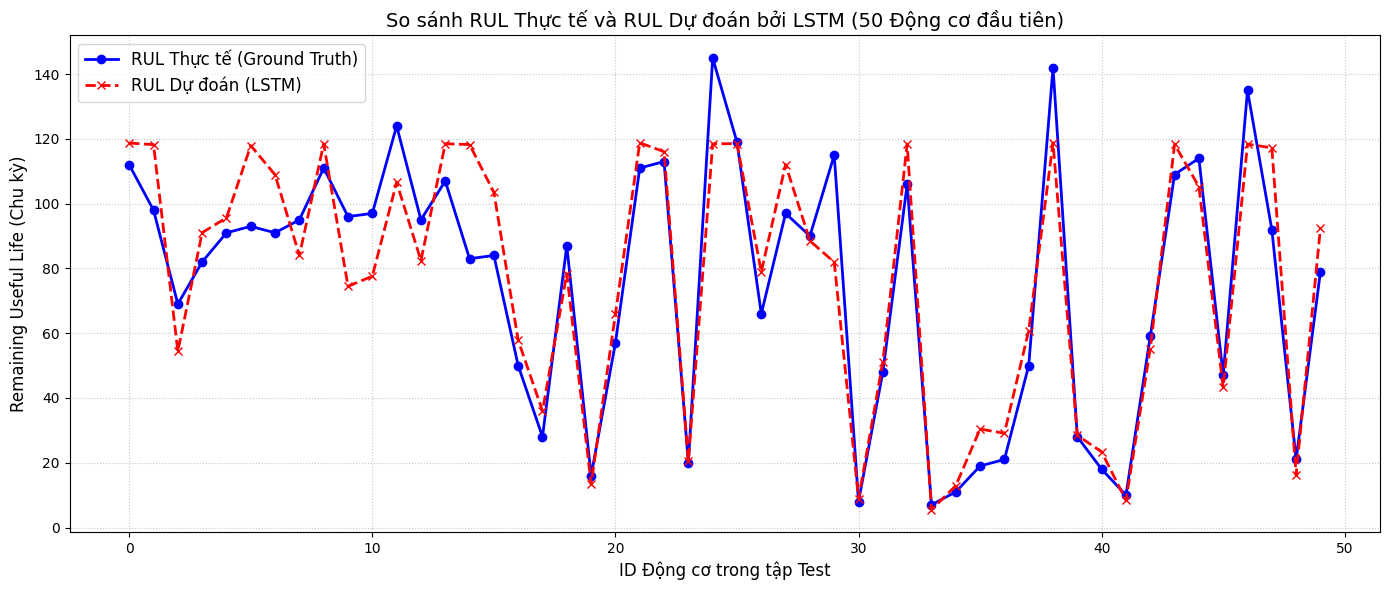

In [16]:
import matplotlib.pyplot as plt

# Sắp xếp lại dữ liệu theo ID động cơ để biểu đồ dễ nhìn hơn
# (Vì tập Test có 100 động cơ, ta vẽ 50 động cơ đầu tiên)
plt.figure(figsize=(14, 6))

# Vẽ đường thực tế và dự đoán
plt.plot(y_test_lstm[:50], label='RUL Thực tế (Ground Truth)', marker='o', color='blue', linewidth=2)
plt.plot(y_pred_lstm_new[:50], label='RUL Dự đoán (LSTM)', marker='x', color='red', linestyle='--', linewidth=2)

plt.title('So sánh RUL Thực tế và RUL Dự đoán bởi LSTM (50 Động cơ đầu tiên)', fontsize=14)
plt.xlabel('ID Động cơ trong tập Test', fontsize=12)
plt.ylabel('Remaining Useful Life (Chu kỳ)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()